In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 🔹 Correct dataset path
BASE_PATH = "../../dataset_new"

TRAIN_PATH = os.path.join(BASE_PATH, "Dataset_Blood_Group_Training")
VAL_PATH = os.path.join(BASE_PATH, "Dataset_Blood_Group_Validation")
TEST_PATH = os.path.join(BASE_PATH, "Dataset_Blood_Group_Testing")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Training Path:", TRAIN_PATH)
print("Validation Path:", VAL_PATH)
print("Testing Path:", TEST_PATH)


Training Path: ../../dataset_new\dataset_training
Validation Path: ../../dataset_new\dataset_validation
Testing Path: ../../dataset_new\dataset_testing


In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_images = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_images = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_images = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 5840 images belonging to 8 classes.
Found 598 images belonging to 8 classes.
Found 600 images belonging to 8 classes.


In [3]:
def build_alexnet(input_shape, num_classes):
    inp = Input(shape=input_shape)
    x = Conv2D(96, (11, 11), strides=(4, 4), activation='relu', padding='same')(inp)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)
    x = Conv2D(256, (5, 5), padding='same', activation='relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)
    x = Conv2D(384, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(384, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)
    x = Flatten()(x)
    x = Dense(4096, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(4096, activation='relu')(x)
    x = Dropout(0.5)(x)
    # Output layer will be added in ensemble
    return Model(inputs=inp, outputs=x, name='AlexNet')

def build_lenet(input_shape, num_classes):
    inp = Input(shape=input_shape)
    x = Conv2D(6, (5, 5), activation='tanh', padding='same')(inp)
    x = AveragePooling2D((2, 2), strides=(2, 2))(x)
    x = Conv2D(16, (5, 5), activation='tanh', padding='valid')(x)
    x = AveragePooling2D((2, 2), strides=(2, 2))(x)
    x = Flatten()(x)
    x = Dense(120, activation='tanh')(x)
    x = Dense(84, activation='tanh')(x)
    return Model(inputs=inp, outputs=x, name='LeNet')

def build_resnet(input_shape, num_classes):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    return Model(inputs=base_model.input, outputs=x, name='ResNet50')

In [8]:
# ==============================
# 🔹 REQUIRED IMPORTS
# ==============================

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, AveragePooling2D,
    Flatten, Dense, Dropout, Concatenate,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam


# ==============================
# 🔹 ALEXNET MODEL
# ==============================

def build_alexnet(input_shape):
    inp = Input(shape=input_shape)

    x = Conv2D(96, (11, 11), strides=(4, 4), activation='relu', padding='same')(inp)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)

    x = Conv2D(256, (5, 5), padding='same', activation='relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)

    x = Conv2D(384, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(384, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)

    x = Flatten()(x)
    x = Dense(4096, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(4096, activation='relu')(x)
    x = Dropout(0.5)(x)

    return Model(inputs=inp, outputs=x, name='AlexNet')


# ==============================
# 🔹 LENET MODEL
# ==============================

def build_lenet(input_shape):
    inp = Input(shape=input_shape)

    x = Conv2D(6, (5, 5), activation='tanh', padding='same')(inp)
    x = AveragePooling2D((2, 2), strides=(2, 2))(x)

    x = Conv2D(16, (5, 5), activation='tanh', padding='valid')(x)
    x = AveragePooling2D((2, 2), strides=(2, 2))(x)

    x = Flatten()(x)
    x = Dense(120, activation='tanh')(x)
    x = Dense(84, activation='tanh')(x)

    return Model(inputs=inp, outputs=x, name='LeNet')


# ==============================
# 🔹 RESNET50 MODEL
# ==============================

def build_resnet(input_shape):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze ResNet base layers
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)

    return Model(inputs=base_model.input, outputs=x, name='ResNet50')


# ==============================
# 🔹 ENSEMBLE MODEL CREATION
# ==============================

input_shape = (224, 224, 3)
num_classes = train_images.num_classes   # from flow_from_directory

# Instantiate models
alexnet = build_alexnet(input_shape)
lenet = build_lenet(input_shape)
resnet = build_resnet(input_shape)

# Shared Input
model_input = Input(shape=input_shape)

# Get outputs
out_alex = alexnet(model_input)
out_lenet = lenet(model_input)
out_res = resnet(model_input)

# Concatenate
combined = Concatenate()([out_alex, out_lenet, out_res])

# Final layers
z = Dense(256, activation='relu')(combined)
z = Dropout(0.5)(z)
output = Dense(num_classes, activation='softmax')(z)

# Create final model
ensemble_model = Model(inputs=model_input, outputs=output, name='Ensemble_Model')


# ==============================
# 🔹 COMPILE MODEL
# ==============================

ensemble_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
ensemble_model.summary()


Model: "Ensemble_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ AlexNet (Functional)          │ (None, 4096)              │      58,281,344 │ input_layer_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ LeNet (Functional)            │ (None, 84)                │       5,611,876 │ input_layer_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ResNet50 (Functional)         │ (None, 1024)              │      25,685,888 │ input_layer_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 5204)              │               0 │ AlexNet[0][0],             │
│                               │                           │                 │ LeNet[0][0],               │
│                               │                           │                 │ ResNet50[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 256)               │       1,332,480 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 256)               │               0 │ dense_5[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 8)                 │           2,056 │ dropout_2[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 90,913,644 (346.81 MB)

 Trainable params: 67,325,932 (256.83 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback

REQUIRED_ACCURACY = 0.90

class StopAtAccuracy(Callback):
    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        if val_acc is not None and val_acc >= REQUIRED_ACCURACY:
            print(f"\nRequired accuracy {REQUIRED_ACCURACY*100}% reached. Stopping training.")
            self.model.stop_training = True

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'ensemble_best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    StopAtAccuracy()
]

try:
    history = ensemble_model.fit(
        train_images,
        validation_data=val_images,
        epochs=30,
        callbacks=callbacks,
        verbose=1
    )

except KeyboardInterrupt:
    print("\nTraining manually stopped by user.")
    ensemble_model.save("manually_stopped_model.h5")
    print("Model saved as manually_stopped_model.h5")


Epoch 1/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2933 - loss: 1.7365  
Epoch 1: val_accuracy improved from None to 0.36622, saving model to ensemble_best_model.h5


183/183 ━━━━━━━━━━━━━━━━━━━━ 417s 2s/step - accuracy: 0.3089 - loss: 1.7090 - val_accuracy: 0.3662 - val_loss: 1.5453
Epoch 2/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3469 - loss: 1.5981  
Epoch 2: val_accuracy did not improve from 0.36622
183/183 ━━━━━━━━━━━━━━━━━━━━ 403s 2s/step - accuracy: 0.3608 - loss: 1.5651 - val_accuracy: 0.3579 - val_loss: 1.4923
Epoch 3/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4012 - loss: 1.4897  
Epoch 3: val_accuracy improved from 0.36622 to 0.47324, saving model to ensemble_best_model.h5


183/183 ━━━━━━━━━━━━━━━━━━━━ 423s 2s/step - accuracy: 0.4137 - loss: 1.4631 - val_accuracy: 0.4732 - val_loss: 1.2318
Epoch 4/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4319 - loss: 1.3948  
Epoch 4: val_accuracy improved from 0.47324 to 0.55184, saving model to ensemble_best_model.h5


183/183 ━━━━━━━━━━━━━━━━━━━━ 439s 2s/step - accuracy: 0.4438 - loss: 1.3624 - val_accuracy: 0.5518 - val_loss: 1.0743
Epoch 5/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4843 - loss: 1.3074  
Epoch 5: val_accuracy improved from 0.55184 to 0.76254, saving model to ensemble_best_model.h5


183/183 ━━━━━━━━━━━━━━━━━━━━ 400s 2s/step - accuracy: 0.5015 - loss: 1.2543 - val_accuracy: 0.7625 - val_loss: 0.7543
Epoch 6/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5696 - loss: 1.1323  
Epoch 6: val_accuracy improved from 0.76254 to 0.78428, saving model to ensemble_best_model.h5


...

183/183 ━━━━━━━━━━━━━━━━━━━━ 402s 2s/step - accuracy: 0.7545 - loss: 0.6524 - val_accuracy: 0.8645 - val_loss: 0.3743
Epoch 21/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7642 - loss: 0.6120  
Epoch 21: val_accuracy did not improve from 0.86455
183/183 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.7646 - loss: 0.6260 - val_accuracy: 0.8378 - val_loss: 0.4069
Epoch 22/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7654 - loss: 0.6125  
Epoch 22: val_accuracy did not improve from 0.86455
183/183 ━━━━━━━━━━━━━━━━━━━━ 402s 2s/step - accuracy: 0.7625 - loss: 0.6215 - val_accuracy: 0.8629 - val_loss: 0.3277
Epoch 23/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7624 - loss: 0.6269  
Epoch 23: val_accuracy improved from 0.86455 to 0.87458, saving model to ensemble_best_model.h5


183/183 ━━━━━━━━━━━━━━━━━━━━ 401s 2s/step - accuracy: 0.7731 - loss: 0.6058 - val_accuracy: 0.8746 - val_loss: 0.3135
Epoch 24/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7902 - loss: 0.5783  
Epoch 24: val_accuracy did not improve from 0.87458
183/183 ━━━━━━━━━━━━━━━━━━━━ 399s 2s/step - accuracy: 0.7793 - loss: 0.5894 - val_accuracy: 0.8629 - val_loss: 0.3288
Epoch 25/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7747 - loss: 0.5732  
Epoch 25: val_accuracy did not improve from 0.87458
183/183 ━━━━━━━━━━━━━━━━━━━━ 401s 2s/step - accuracy: 0.7728 - loss: 0.6012 - val_accuracy: 0.7876 - val_loss: 0.5328
Epoch 26/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7780 - loss: 0.6003  
Epoch 26: val_accuracy improved from 0.87458 to 0.88629, saving model to ensemble_best_model.h5


183/183 ━━━━━━━━━━━━━━━━━━━━ 409s 2s/step - accuracy: 0.7781 - loss: 0.5935 - val_accuracy: 0.8863 - val_loss: 0.3077
Epoch 27/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7919 - loss: 0.5571  
Epoch 27: val_accuracy did not improve from 0.88629
183/183 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.7920 - loss: 0.5689 - val_accuracy: 0.8629 - val_loss: 0.3454
Epoch 28/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7955 - loss: 0.5575  
Epoch 28: val_accuracy did not improve from 0.88629
183/183 ━━━━━━━━━━━━━━━━━━━━ 397s 2s/step - accuracy: 0.7914 - loss: 0.5697 - val_accuracy: 0.8462 - val_loss: 0.3868
Epoch 29/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7943 - loss: 0.5716  
Epoch 29: val_accuracy improved from 0.88629 to 0.89130, saving model to ensemble_best_model.h5


183/183 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.7943 - loss: 0.5720 - val_accuracy: 0.8913 - val_loss: 0.3002
Epoch 30/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7906 - loss: 0.5628  
Epoch 30: val_accuracy improved from 0.89130 to 0.91639, saving model to ensemble_best_model.h5



Required accuracy 90.0% reached. Stopping training.
183/183 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.7844 - loss: 0.5633 - val_accuracy: 0.9164 - val_loss: 0.2556
Restoring model weights from the end of the best epoch: 30.


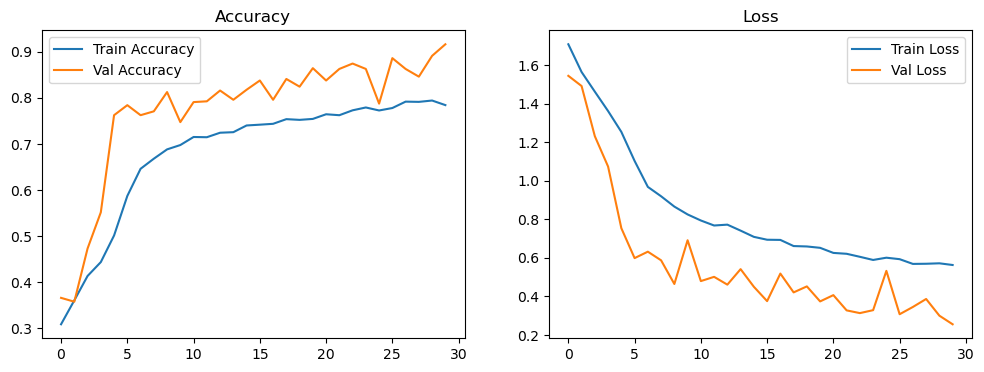

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()


C:\Users\chait\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Test Accuracy: 91.33%
19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step
              precision    recall  f1-score   support

          A+       0.92      0.91      0.91        75
          A-       0.91      0.84      0.88        75
         AB+       0.92      0.96      0.94        75
         AB-       0.98      0.87      0.92        75
          B+       0.91      0.97      0.94        75
          B-       0.91      0.97      0.94        75
          O+       0.84      0.95      0.89        75
          O-       0.93      0.84      0.88        75

    accuracy                           0.91       600
   macro avg       0.92      0.91      0.91       600
weighted avg       0.92      0.91      0.91       600



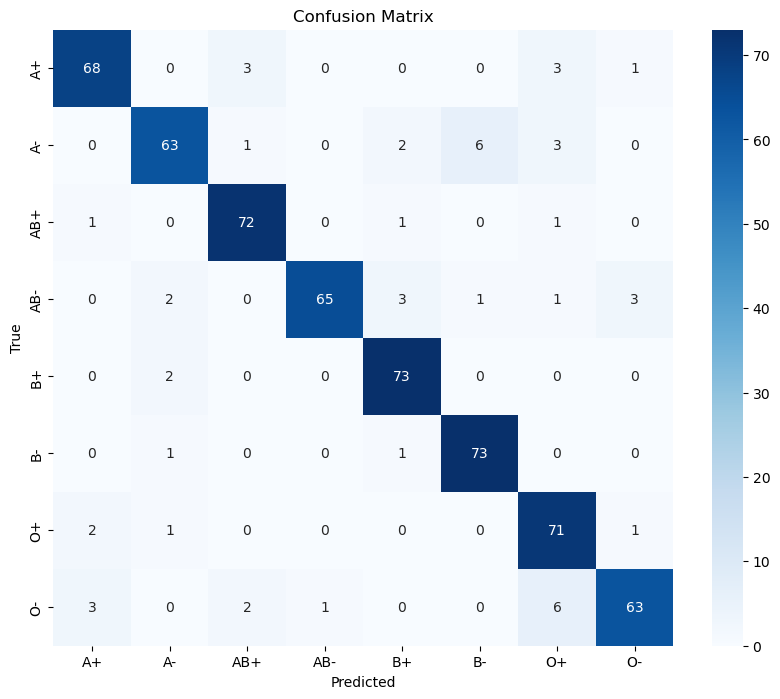

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

results = ensemble_model.evaluate(test_images, verbose=0)
print(f"\nTest Accuracy: {results[1]*100:.2f}%")

pred_probs = ensemble_model.predict(test_images)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = test_images.classes

print(classification_report(
    true_labels,
    pred_labels,
    target_names=list(test_images.class_indices.keys())
))

plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion_matrix(true_labels, pred_labels),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(test_images.class_indices.keys()),
    yticklabels=list(test_images.class_indices.keys())
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


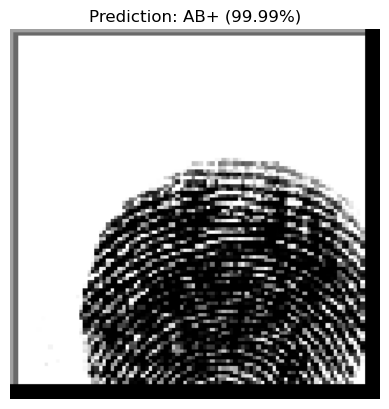

In [16]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

model = load_model('ensemble_best_model.h5')

class_labels = list(train_images.class_indices.keys())
class_labels = dict((v, k) for k, v in train_images.class_indices.items())

img_path = "../../dataset_new/dataset_testing/AB+/cluster_4_191.BMP"

img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = x / 255.0
x = np.expand_dims(x, axis=0)

result = model.predict(x)
predicted_class = np.argmax(result)
predicted_label = class_labels[predicted_class]
confidence = result[0][predicted_class] * 100

plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)")
plt.show()
